In [1]:
!pip install -q transformers datasets scikit-learn pandas matplotlib seaborn accelerate

In [2]:
import os
import re
import html
import json
import warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive, files
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)

warnings.filterwarnings('ignore')
print("All libraries imported!")

All libraries imported!


In [3]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU detected. Training will be very slow!")

PyTorch version: 2.9.0+cu126
CUDA available: True
GPU: Tesla T4
Memory: 15.8 GB


In [4]:
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
uploaded = files.upload()  # Upload dataset_merged.csv

Saving dataset_kesehatan.csv to dataset_kesehatan.csv
Saving dataset_pendidikan.csv to dataset_pendidikan.csv


In [43]:
# =============================================================================
# CONFIGURATION
# =============================================================================

# Model configs
# Kita menggunakan mBERT (Multilingual BERT) dan XLM-RoBERTa
# Keduanya adalah model bahasa yang pre-trained dalam banyak bahasa (termasuk Indonesia)
MBERT_MODEL = "bert-base-multilingual-cased"
XLMR_MODEL = "xlm-roberta-base"
INDOBERT_MODEL = "indobenchmark/indobert-base-p1"

# Label mapping (original 1-7 -> 0-6)
# Mengubah label dataset dari 1-7 menjadi 0-6 agar sesuai format PyTorch
LABEL_NAMES = {
    0: "senang",
    1: "percaya",
    2: "terkejut",
    3: "netral",
    4: "takut",
    5: "sedih",
    6: "marah"
}
LABEL_MAPPING = {1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5, 7: 6}
NUM_LABELS = 7

# Training hyperparameters

# MAX_LENGTH: Panjang maksimal teks (dalam token) yang akan diproses model.
# Teks yang lebih panjang akan dipotong (truncated), yang lebih pendek akan di-isi (padded).
# BERT memiliki batas maksimal 512.
# Nanti kita akan hitung nilai optimal berdasarkan dataset.
MAX_LENGTH = 512  # Default awal, bisa diubah dinamis
MAX_LENGTH_MBERT = 512
MAX_LENGTH_XLMR = 512
MAX_LENGTH_INDOBERT = 512

# BATCH_SIZE: Jumlah data yang diproses model dalam satu kali jalan (forward & backward pass).
# Semakin besar batch, semakin cepat training, tapi butuh memory (VRAM) besar.
# Jika error "Out of Memory", kurangi jadi 8 atau 4.
BATCH_SIZE = 16

# LEARNING_RATE: Seberapa "cepat" model belajar.
# Jika terlalu besar (misal 1e-1), model tidak bisa konvergen (hasil jelek/naik turun).
# Jika terlalu kecil (misal 1e-7), training sangat lama.
# 2e-5 (0.00002) adalah standar emas untuk fine-tuning BERT.
LEARNING_RATE = 2e-5

# NUM_EPOCHS: Berapa kali model melihat SELURUH dataset training.
# 3-5 epoch biasanya cukup untuk fine-tuning.
NUM_EPOCHS = 3

# WARMUP_RATIO: Persentase langkah awal training di mana learning rate naik perlahan dari 0.
# Ini mencegah model "kaget" di awal training yang bisa merusak bobot pre-trained.
WARMUP_RATIO = 0.1

# WEIGHT_DECAY: Teknik regularisasi untuk mencegah overfitting.
# Memberi penalti pada bobot model yang terlalu besar.
WEIGHT_DECAY = 0.01

# Data split
# Pembagian dataset: 80% Train, 10% Validation, 10% Test
TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1
RANDOM_SEED = 42

# Paths
DATA_PATH = "dataset_pendidikan.csv"
OUTPUT_DIR_MBERT = "./results/mbert"
OUTPUT_DIR_XLMR = "./results/xlmr"
OUTPUT_DIR_INDOBERT = "./results/indobert"
PROCESSED_DATA_DIR = "./processed_data"

print("Configuration loaded!")

Configuration loaded!


In [44]:
def clean_text(text):
    """
    Membersihkan teks dari noise (Minimal Preprocessing).
    Untuk BERT/XLM-R, kita TIDAK perlu melakukan stemming, lemmatization, atau lowercase.
    Model ini butuh konteks, tanda baca, dan kapitalisasi untuk memahami emosi.
    """
    if not isinstance(text, str):
        return ""

    # Decode HTML entities (tetap perlu, karena artefak scraping)
    text = html.unescape(text)

    # Remove URLs (URL biasanya tidak mengandung emosi)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r't\.co/\S+', '', text)

    # Remove mentions (@username) - Opsional, tapi biasanya @user tidak relevan dengan emosi kalimat
    text = re.sub(r'@\w+', '', text)

    # JANGAN HAPUS HASHTAG (#)
    # Hashtag #senang dan kata "senang" itu mirip.
    # Kita hanya hapus simbol #-nya saja, tapi katanya biarkan.
    text = re.sub(r'#(\w+)', r'\1', text)

    # Fix encoding issues (tetap perlu)
    text = text.replace('\u00c3\u00a2\u00c2\u00c2', '')
    text = text.replace('&amp;', '&')

    # normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # NOTE:
    # 1. Tidak ada .lower() -> Kapitalisasi (MARAH vs marah) itu penting!
    # 2. Tidak ada remove punctuation -> "APA??" vs "apa" itu beda emosinya.
    # 3. Tidak ada remove stopword -> "saya tidak suka" vs "saya suka" (kata 'tidak' penting).
    # 4. Tidak ada remove emoji -> Emoji adalah sinyal emosi terkuat!
    # 5. Tidak ada remove angka -> "100% setuju", "Juara 1", "2024" sering punya konteks emosi/intensitas.
    #    Tokenizer BERT/XLM-R bisa menangani angka dengan baik.

    return text


# Test preprocessing
test_text = "@user Ini contoh teks! #EmotionAI https://t.co/abc123 &amp; lainnya"
print(f"Original: {test_text}")
print(f"Cleaned:  {clean_text(test_text)}")

Original: @user Ini contoh teks! #EmotionAI https://t.co/abc123 &amp; lainnya
Cleaned:  Ini contoh teks! EmotionAI & lainnya


Analyzing token lengths for bert-base-multilingual-cased...
  Average length: 48.6
  Max length:     232
  95th percentile: 75.0
  99th percentile: 86.0


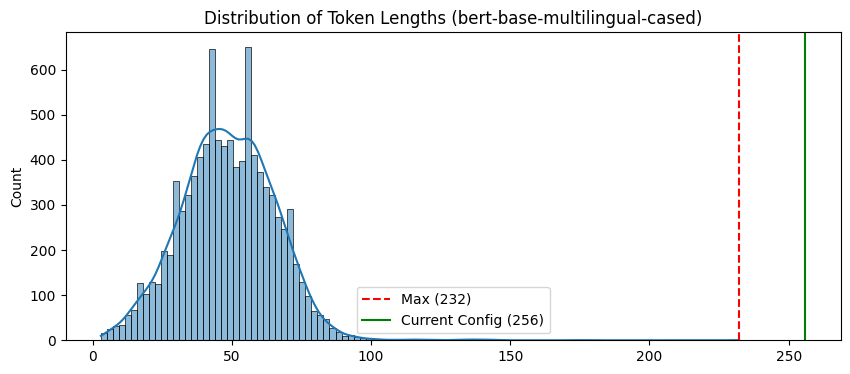

NOTE: Max length (256) jauh lebih besar dari p99 (86).
      Ini mungkin boros memori jika hanya ada 1-2 kalimat yang sangat panjang.
      Pertimbangkan manual set MAX_LENGTH ke nilai p99.
REKOMENDASI MAX_LENGTH: 86
Analyzing token lengths for xlm-roberta-base...


Token indices sequence length is longer than the specified maximum sequence length for this model (592 > 512). Running this sequence through the model will result in indexing errors


  Average length: 39.8
  Max length:     592
  95th percentile: 62.0
  99th percentile: 72.0


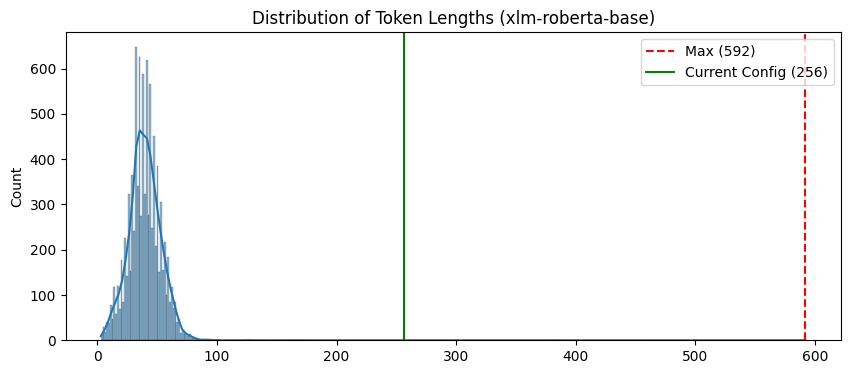

NOTE: Max length (512) jauh lebih besar dari p99 (72).
      Ini mungkin boros memori jika hanya ada 1-2 kalimat yang sangat panjang.
      Pertimbangkan manual set MAX_LENGTH ke nilai p99.
REKOMENDASI MAX_LENGTH: 72
Analyzing token lengths for indobenchmark/indobert-base-p1...
  Average length: 30.6
  Max length:     76
  95th percentile: 50.0
  99th percentile: 57.0


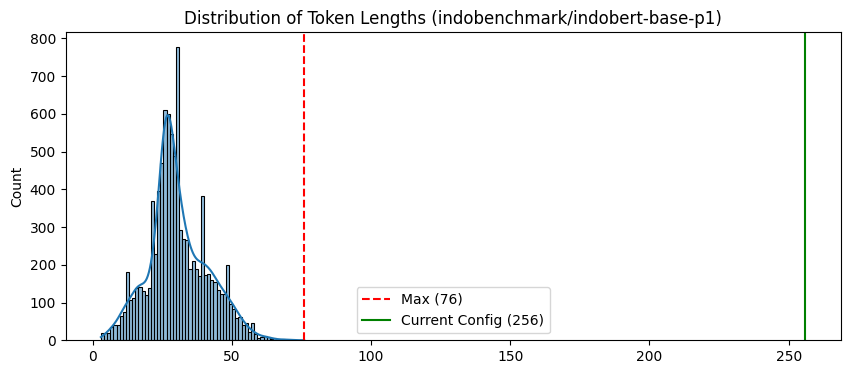

REKOMENDASI MAX_LENGTH: 96
Updated MAX_LENGTH_MBERT to 86
Updated MAX_LENGTH_XLMR to 72
Updated MAX_LENGTH_INDOBERT to 96
Updated MAX_LENGTH to 96


In [45]:
def get_optimal_max_length(model_name, sample_ratio=0.5):
    """
    Hitung distribusi panjang token dalam dataset untuk menentukan MAX_LENGTH optimal.

    Args:
        model_name: Nama model (untuk tokenizer)
        sample_ratio: Persentase data yang digunakan untuk sampling (default 50% biar cepat)
    """
    print(f"Analyzing token lengths for {model_name}...")

    # Load raw data first
    df = pd.read_csv(DATA_PATH, sep=';', encoding='utf-8')
    df['text'] = df['full_text'].apply(clean_text)

    # Sample data
    if sample_ratio < 1.0:
        df = df.sample(frac=sample_ratio, random_state=42)

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    # Hitung panjang token untuk setiap kalimat
    token_lens = []
    for txt in df['text']:
        tokens = tokenizer.encode(txt, add_special_tokens=True)
        token_lens.append(len(tokens))

    # Statistik
    avg_len = np.mean(token_lens)
    max_len = np.max(token_lens)
    p95 = np.percentile(token_lens, 95)
    p99 = np.percentile(token_lens, 99)

    print(f"  Average length: {avg_len:.1f}")
    print(f"  Max length:     {max_len}")
    print(f"  95th percentile: {p95:.1f}")
    print(f"  99th percentile: {p99:.1f}")

    # Visualisasi
    plt.figure(figsize=(10, 4))
    sns.histplot(token_lens, kde=True)
    plt.axvline(max_len, color='red', linestyle='--', label=f'Max ({int(max_len)})')
    plt.axvline(256, color='green', linestyle='-', label='Current Config (256)')
    plt.title(f'Distribution of Token Lengths ({model_name})')
    plt.legend()
    plt.show()

    # Rekomendasi
    # Menggunakan panjang MAXIMAL dari dataset, tapi tidak boleh melebihi batas model (512)
    suggested_len = int(max_len) + 2 # Sedikit buffer

    # Clamp ke 512 (batas absolut BERT/XLM-R)
    if suggested_len > 512:
        suggested_len = 512
        print("WARNING: Ada teks yang lebih panjang dari 512 token, akan dipotong!")

    # Round up to nearest 32 (optimized for GPU)
    suggested_len = ((suggested_len + 31) // 32) * 32

    # Cek efisiensi
    if suggested_len > p99 + 50:
        print(f"NOTE: Max length ({suggested_len}) jauh lebih besar dari p99 ({int(p99)}).")
        print("      Ini mungkin boros memori jika hanya ada 1-2 kalimat yang sangat panjang.")
        print("      Pertimbangkan manual set MAX_LENGTH ke nilai p99.")
        suggested_len = int(p99)

    print(f"REKOMENDASI MAX_LENGTH: {suggested_len}")
    return suggested_len

# Jalankan analisis
sorted_len_mbert = get_optimal_max_length(MBERT_MODEL)
sorted_len_xlmr = get_optimal_max_length(XLMR_MODEL)
sorted_len_indobert = get_optimal_max_length(INDOBERT_MODEL)


# Update MAX_LENGTH global variable dengan rekomendasi
MAX_LENGTH_MBERT = sorted_len_mbert
MAX_LENGTH_XLMR = sorted_len_xlmr
MAX_LENGTH_INDOBERT = sorted_len_indobert
MAX_LENGTH = max(sorted_len_mbert, sorted_len_xlmr, sorted_len_indobert)
print(f"Updated MAX_LENGTH_MBERT to {MAX_LENGTH_MBERT}")
print(f"Updated MAX_LENGTH_XLMR to {MAX_LENGTH_XLMR}")
print(f"Updated MAX_LENGTH_INDOBERT to {MAX_LENGTH_INDOBERT}")
print(f"Updated MAX_LENGTH to {MAX_LENGTH}")

In [47]:
def prepare_dataset():
    """Prepare dataset dengan preprocessing dan split."""
    print("Loading data...")
    df = pd.read_csv(DATA_PATH, sep=';', encoding='utf-8')
    print(f"Total rows: {len(df):,}")

    # Clean data
    df = df.dropna(subset=['manual_label'])
    df['manual_label'] = pd.to_numeric(df['manual_label'], errors='coerce')
    df = df.dropna(subset=['manual_label'])
    df['manual_label'] = df['manual_label'].astype(int)
    df = df[df['manual_label'].isin([1, 2, 3, 4, 5, 6, 7])]
    print(f"Valid rows: {len(df):,}")

    # Preprocess text
    print("Preprocessing text...")
    df['text'] = df['full_text'].apply(clean_text)
    df = df[df['text'].str.len() > 0]

    # Map labels (1-7 -> 0-6)
    df['label'] = df['manual_label'].map(LABEL_MAPPING)

    # Compute class weights
    print("Computing class weights...")
    classes = np.unique(df['label'])
    weights = compute_class_weight('balanced', classes=classes, y=df['label'])
    class_weights = {int(c): float(w) for c, w in zip(classes, weights)}

    for label_id, weight in sorted(class_weights.items()):
        print(f"  {label_id} ({LABEL_NAMES[label_id]}): {weight:.4f}")

    # Split data
    print(f"Splitting data ({TRAIN_RATIO}/{VAL_RATIO}/{TEST_RATIO})...")
    train_df, temp_df = train_test_split(
        df, train_size=TRAIN_RATIO, random_state=RANDOM_SEED, stratify=df['label']
    )
    val_size = VAL_RATIO / (VAL_RATIO + TEST_RATIO)
    val_df, test_df = train_test_split(
        temp_df, train_size=val_size, random_state=RANDOM_SEED, stratify=temp_df['label']
    )

    print(f"  Train: {len(train_df):,}")
    print(f"  Val:   {len(val_df):,}")
    print(f"  Test:  {len(test_df):,}")

    # Create HuggingFace Dataset
    dataset = DatasetDict({
        'train': Dataset.from_pandas(train_df[['text', 'label']], preserve_index=False),
        'validation': Dataset.from_pandas(val_df[['text', 'label']], preserve_index=False),
        'test': Dataset.from_pandas(test_df[['text', 'label']], preserve_index=False)
    })

    print(dataset)

    # Save
    os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)
    dataset.save_to_disk(PROCESSED_DATA_DIR)
    with open(os.path.join(PROCESSED_DATA_DIR, 'class_weights.json'), 'w') as f:
        json.dump(class_weights, f)

    print(f"Dataset saved to {PROCESSED_DATA_DIR}")
    return dataset, class_weights


dataset, class_weights = prepare_dataset()

Loading data...
Total rows: 19,177
Valid rows: 19,174
Preprocessing text...
Computing class weights...
  0 (senang): 1.2770
  1 (percaya): 1.2770
  2 (terkejut): 1.2800
  3 (netral): 0.4654
  4 (takut): 1.2830
  5 (sedih): 1.2770
  6 (marah): 1.0621
Splitting data (0.8/0.1/0.1)...
  Train: 15,339
  Val:   1,917
  Test:  1,918
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 15339
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1917
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1918
    })
})


Saving the dataset (0/1 shards):   0%|          | 0/15339 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1917 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1918 [00:00<?, ? examples/s]

Dataset saved to ./processed_data


In [49]:
print("Sample data:")
for i in range(5):
    sample = dataset['train'][i]
    label = sample['label']
    text = sample['text'][:80]
    print(f"  [{i}] Label {label} ({LABEL_NAMES[label]}): {text}...")

Sample data:
  [0] Label 3 (netral): bayangin di sekolah adik ai ada acara lomba-lomba orang tua dan bentukan mereka ...
  [1] Label 3 (netral): Mungkin pemerintah mengalokasikan anggaran berdasarkan prioritas pendidikan untu...
  [2] Label 0 (senang): Salut Kapolri dan semua pemenang Hoegeng Awards 2025! Dari pendidikan gratis sam...
  [3] Label 3 (netral): KOTA JANTHO - Dinas Pendidikan dan Kebudayaan (Disdikbud) Aceh Besar bersama Ban...
  [4] Label 3 (netral): Setelah dana bos cair (per 6 bulan) gaji bisa datang tiap bulan. Eh pas udah dap...


In [50]:
def test_tokenization(model_name, sample_texts, max_length):
    """Test bagaimana tokenizer memproses teks."""
    print(f"\n{'='*60}")
    print(f"Tokenizer: {model_name}")
    print('='*60)

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    for text in sample_texts:
        print(f"\nOriginal: {text}")
        cleaned = clean_text(text)
        print(f"Cleaned:  {cleaned}")

        # Tokenize
        tokens = tokenizer.tokenize(cleaned)
        token_ids = tokenizer.encode(cleaned, add_special_tokens=True)

        print(f"Tokens ({len(tokens)}): {tokens[:15]}{'...' if len(tokens) > 15 else ''}")
        print(f"Token IDs: {token_ids[:10]}{'...' if len(token_ids) > 10 else ''}")

        # Check truncation
        full_encoding = tokenizer(
            cleaned,
            truncation=True,
            max_length=max_length,
            padding=True
        )
        print(f"Final length: {len(full_encoding['input_ids'])} (max: {max_length})")


# Test dengan beberapa sample
sample_texts = [
    "Wah senang banget hari ini! Akhirnya bisa liburan 🎉",
    "Sedih banget denger berita itu, semoga keluarganya tabah ya",
    "Marah banget gue sama dia! Udah dikasih tau berkali-kali tetep aja"
]

print("Testing mBERT tokenizer:")
test_tokenization(MBERT_MODEL, sample_texts, MAX_LENGTH_MBERT)

print("\n" + "="*60)
print("Testing XLM-RoBERTa tokenizer:")
test_tokenization(XLMR_MODEL, sample_texts, MAX_LENGTH_XLMR)

print("\n" + "="*60)
print("Testing IndoBERT tokenizer:")
test_tokenization(INDOBERT_MODEL, sample_texts, MAX_LENGTH_INDOBERT)

Testing mBERT tokenizer:

Tokenizer: bert-base-multilingual-cased

Original: Wah senang banget hari ini! Akhirnya bisa liburan 🎉
Cleaned:  Wah senang banget hari ini! Akhirnya bisa liburan 🎉
Tokens (16): ['W', '##ah', 'sen', '##ang', 'bang', '##et', 'hari', 'ini', '!', 'Ak', '##hir', '##nya', 'bisa', 'lib', '##uran']...
Token IDs: [101, 160, 12257, 12954, 11889, 17937, 10308, 18370, 10592, 106]...
Final length: 18 (max: 86)

Original: Sedih banget denger berita itu, semoga keluarganya tabah ya
Cleaned:  Sedih banget denger berita itu, semoga keluarganya tabah ya
Tokens (17): ['Se', '##di', '##h', 'bang', '##et', 'den', '##ger', 'berita', 'itu', ',', 'sem', '##oga', 'keluarga', '##nya', 'taba']...
Token IDs: [101, 11045, 10703, 10237, 17937, 10308, 10140, 11446, 84836, 11910]...
Final length: 19 (max: 86)

Original: Marah banget gue sama dia! Udah dikasih tau berkali-kali tetep aja
Cleaned:  Marah banget gue sama dia! Udah dikasih tau berkali-kali tetep aja
Tokens (24): ['Mara', '##h', 

In [51]:
def count_parameters(model_name):
    """Hitung jumlah parameter model."""
    print(f"\n{'='*60}")
    print(f"Model: {model_name}")
    print('='*60)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=NUM_LABELS
    )

    # Total parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"Total parameters:     {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    print(f"Memory estimate:      ~{total_params * 4 / 1e9:.2f} GB (FP32)")
    print(f"Memory estimate:      ~{total_params * 2 / 1e9:.2f} GB (FP16)")

    # Parameter breakdown by layer type
    print("\nParameter breakdown:")
    embeddings = sum(p.numel() for n, p in model.named_parameters() if 'embedding' in n.lower())
    encoder = sum(p.numel() for n, p in model.named_parameters() if 'encoder' in n.lower() or 'layer' in n.lower())
    classifier = sum(p.numel() for n, p in model.named_parameters() if 'classifier' in n.lower())

    print(f"  Embeddings:  {embeddings:,} ({embeddings/total_params*100:.1f}%)")
    print(f"  Encoder:     {encoder:,} ({encoder/total_params*100:.1f}%)")
    print(f"  Classifier:  {classifier:,} ({classifier/total_params*100:.1f}%)")

    del model
    torch.cuda.empty_cache()

    return total_params, trainable_params


print("Counting parameters...")
mbert_params = count_parameters(MBERT_MODEL)
xlmr_params = count_parameters(XLMR_MODEL)
indobert_params = count_parameters(INDOBERT_MODEL)

Counting parameters...

Model: bert-base-multilingual-cased


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters:     177,858,823
Trainable parameters: 177,858,823
Memory estimate:      ~0.71 GB (FP32)
Memory estimate:      ~0.36 GB (FP16)

Parameter breakdown:
  Embeddings:  92,208,384 (51.8%)
  Encoder:     85,056,000 (47.8%)
  Classifier:  5,383 (0.0%)

Model: xlm-roberta-base


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters:     278,049,031
Trainable parameters: 278,049,031
Memory estimate:      ~1.11 GB (FP32)
Memory estimate:      ~0.56 GB (FP16)

Parameter breakdown:
  Embeddings:  192,398,592 (69.2%)
  Encoder:     85,056,000 (30.6%)
  Classifier:  595,975 (0.2%)

Model: indobenchmark/indobert-base-p1


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters:     124,446,727
Trainable parameters: 124,446,727
Memory estimate:      ~0.50 GB (FP32)
Memory estimate:      ~0.25 GB (FP16)

Parameter breakdown:
  Embeddings:  38,796,288 (31.2%)
  Encoder:     85,056,000 (68.3%)
  Classifier:  5,383 (0.0%)


In [52]:
def freeze_base_model(model):
    """
    Freeze semua layer (Encoder & Embeddings) KECUALI Classifier dan Pooler.
    Hanya Classifier dan Pooler yang akan belajar (Trainable).
    """
    print(f"\n{'='*20} FREEZING BASE MODEL {'='*20}")

    for name, param in model.named_parameters():
        # JANGAN freeze jika layer adalah 'classifier' atau 'pooler'
        # Layer 'classifier' adalah head untuk klasifikasi
        # Layer 'pooler' (di BERT) juga sebaiknya tetap trainable
        if "classifier" in name or "pooler" in name:
            param.requires_grad = True
        else:
            # Selebihnya (Embeddings, Encoder) di-freeze
            param.requires_grad = False

    # Tampilkan status
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())

    print("Status: Base Model FROZEN (Encoder + Embeddings).")
    print("        Hanya Classifier & Pooler yang TRAINABLE.")
    print(f"Total Params:     {total_params:,}")
    print(f"Trainable Params: {trainable_params:,} ({trainable_params/total_params:.1%})")
    print("="*60)

    return model

print("Fungsi freeze_base_model siap digunakan!")

Fungsi freeze_base_model siap digunakan!


In [53]:
def tokenize_dataset(dataset, tokenizer, max_length):
    """Tokenize dataset."""
    def tokenize_fn(examples):
        return tokenizer(
            examples['text'],
            padding=False,
            truncation=True,
            max_length=max_length
        )
    return dataset.map(tokenize_fn, batched=True, remove_columns=['text'])


print("Tokenize function ready!")

Tokenize function ready!


In [54]:
def compute_metrics(eval_pred):
    """Compute evaluation metrics."""
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=-1)

    return {
        'accuracy': accuracy_score(labels, predictions),
        'f1_macro': f1_score(labels, predictions, average='macro'),
        'f1_weighted': f1_score(labels, predictions, average='weighted'),
        'precision_macro': precision_score(labels, predictions, average='macro'),
        'recall_macro': recall_score(labels, predictions, average='macro')
    }


print("Compute metrics function ready!")

Compute metrics function ready!


In [55]:
class WeightedTrainer(Trainer):
    """Custom Trainer dengan weighted loss untuk imbalanced data."""

    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        if class_weights is not None:
            self.class_weights = class_weights.to(self.args.device)
        else:
            self.class_weights = None

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        if self.class_weights is not None:
            loss_fn = torch.nn.CrossEntropyLoss(weight=self.class_weights)
        else:
            loss_fn = torch.nn.CrossEntropyLoss()

        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss


print("WeightedTrainer class ready!")

WeightedTrainer class ready!


In [56]:
def train_model(model_name, output_dir, max_length, use_weighted_loss=True, freeze_base=False):
    """
    Train model dengan konfigurasi yang sudah ditentukan.

    Args:
        model_name: Nama model (MBERT_MODEL atau XLMR_MODEL)
        output_dir: Direktori output untuk save model
        use_weighted_loss: Gunakan weighted loss untuk imbalanced data
        freeze_base: Jika True, freeze base model (hanya classifier & pooler trainable)
    """
    print("=" * 60)
    print(f"TRAINING: {model_name}")
    print("=" * 60)

    # Load tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    # Tokenize
    print("Tokenizing...")
    tokenized = tokenize_dataset(dataset, tokenizer, max_length)

    # Load model
    print(f"Loading model...")
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=NUM_LABELS,
        id2label={i: LABEL_NAMES[i] for i in range(NUM_LABELS)},
        label2id={LABEL_NAMES[i]: i for i in range(NUM_LABELS)}
    )

    # Optional: Freeze base model
    if freeze_base:
        model = freeze_base_model(model)

    # Enable gradient checkpointing untuk memory efficiency
    model.gradient_checkpointing_enable()

    # Prepare class weights tensor
    weights_tensor = None
    if use_weighted_loss:
        weights_list = [class_weights[i] for i in range(NUM_LABELS)]
        weights_tensor = torch.tensor(weights_list, dtype=torch.float32)
        print(f"Using weighted loss: {[f'{w:.2f}' for w in weights_list]}")

    # Training args
    training_args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE * 2,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        warmup_steps=WARMUP_RATIO,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        fp16=torch.cuda.is_available(),
        gradient_accumulation_steps=2,
        logging_steps=100,
        report_to="none",
        seed=RANDOM_SEED
    )

    # Data collator
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    # Trainer
    if use_weighted_loss:
        trainer = WeightedTrainer(
            class_weights=weights_tensor,
            model=model,
            args=training_args,
            train_dataset=tokenized['train'],
            eval_dataset=tokenized['validation'],
            processing_class=tokenizer,
            data_collator=data_collator,
            compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
        )
    else:
        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=tokenized['train'],
            eval_dataset=tokenized['validation'],
            processing_class=tokenizer,
            data_collator=data_collator,
            compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
        )

    # Train
    print("Starting training...")
    trainer.train()

    # Save
    trainer.save_model(output_dir)
    tokenizer.save_pretrained(output_dir)
    print(f"Model saved to {output_dir}")

    # Evaluate on test
    print("\nEvaluating on test set...")
    test_results = trainer.evaluate(tokenized['test'])

    for key, value in test_results.items():
        if isinstance(value, float):
            print(f"  {key}: {value:.4f}")

    # Classification report
    predictions = trainer.predict(tokenized['test'])
    preds = np.argmax(predictions.predictions, axis=-1)
    labels = predictions.label_ids

    print("\nClassification Report:")
    target_names = [LABEL_NAMES[i] for i in range(NUM_LABELS)]
    print(classification_report(labels, preds, target_names=target_names))

    return trainer, test_results, tokenized


print("Training function ready!")

Training function ready!


In [57]:
mbert_trainer, mbert_results, mbert_tokenized = train_model(MBERT_MODEL, OUTPUT_DIR_MBERT, MAX_LENGTH_MBERT)

TRAINING: bert-base-multilingual-cased
Tokenizing...


Map:   0%|          | 0/15339 [00:00<?, ? examples/s]

Map:   0%|          | 0/1917 [00:00<?, ? examples/s]

Map:   0%|          | 0/1918 [00:00<?, ? examples/s]

Loading model...


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./results/mbert

Evaluating on test set...


  eval_loss: 0.5139
  eval_accuracy: 0.8060
  eval_f1_macro: 0.8197
  eval_f1_weighted: 0.8087
  eval_precision_macro: 0.8221
  eval_recall_macro: 0.8205
  eval_runtime: 2.4264
  eval_samples_per_second: 790.4700
  eval_steps_per_second: 24.7280
  epoch: 3.0000

Classification Report:
              precision    recall  f1-score   support

      senang       0.67      0.77      0.71       214
     percaya       0.97      0.90      0.93       215
    terkejut       0.98      0.93      0.95       214
      netral       0.80      0.75      0.78       589
       takut       0.96      0.92      0.94       213
       sedih       0.71      0.70      0.71       215
       marah       0.66      0.78      0.71       258

    accuracy                           0.81      1918
   macro avg       0.82      0.82      0.82      1918
weighted avg       0.81      0.81      0.81      1918



In [58]:
xlmr_trainer, xlmr_results, xlmr_tokenized = train_model(XLMR_MODEL, OUTPUT_DIR_XLMR, MAX_LENGTH_XLMR)

TRAINING: xlm-roberta-base
Tokenizing...


Map:   0%|          | 0/15339 [00:00<?, ? examples/s]

Map:   0%|          | 0/1917 [00:00<?, ? examples/s]

Map:   0%|          | 0/1918 [00:00<?, ? examples/s]

Loading model...


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./results/xlmr

Evaluating on test set...


  eval_loss: 0.4656
  eval_accuracy: 0.8274
  eval_f1_macro: 0.8398
  eval_f1_weighted: 0.8285
  eval_precision_macro: 0.8345
  eval_recall_macro: 0.8494
  eval_runtime: 1.9918
  eval_samples_per_second: 962.9480
  eval_steps_per_second: 30.1230
  epoch: 3.0000

Classification Report:
              precision    recall  f1-score   support

      senang       0.68      0.85      0.76       214
     percaya       0.93      0.96      0.94       215
    terkejut       1.00      0.93      0.96       214
      netral       0.85      0.75      0.79       589
       takut       0.94      0.94      0.94       213
       sedih       0.73      0.73      0.73       215
       marah       0.72      0.78      0.75       258

    accuracy                           0.83      1918
   macro avg       0.83      0.85      0.84      1918
weighted avg       0.83      0.83      0.83      1918



In [62]:
indobert_trainer, indobert_results, indobert_tokenized = train_model(INDOBERT_MODEL, OUTPUT_DIR_INDOBERT, MAX_LENGTH_INDOBERT)

TRAINING: indobenchmark/indobert-base-p1
Tokenizing...


Map:   0%|          | 0/15339 [00:00<?, ? examples/s]

Map:   0%|          | 0/1917 [00:00<?, ? examples/s]

Map:   0%|          | 0/1918 [00:00<?, ? examples/s]

Loading model...


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./results/indobert

Evaluating on test set...


  eval_loss: 0.5307
  eval_accuracy: 0.8160
  eval_f1_macro: 0.8280
  eval_f1_weighted: 0.8160
  eval_precision_macro: 0.8258
  eval_recall_macro: 0.8322
  eval_runtime: 1.6587
  eval_samples_per_second: 1156.3080
  eval_steps_per_second: 36.1720
  epoch: 3.0000

Classification Report:
              precision    recall  f1-score   support

      senang       0.71      0.78      0.74       214
     percaya       0.96      0.95      0.96       215
    terkejut       0.99      0.95      0.97       214
      netral       0.80      0.76      0.78       589
       takut       0.83      0.93      0.88       213
       sedih       0.80      0.73      0.76       215
       marah       0.69      0.72      0.71       258

    accuracy                           0.82      1918
   macro avg       0.83      0.83      0.83      1918
weighted avg       0.82      0.82      0.82      1918



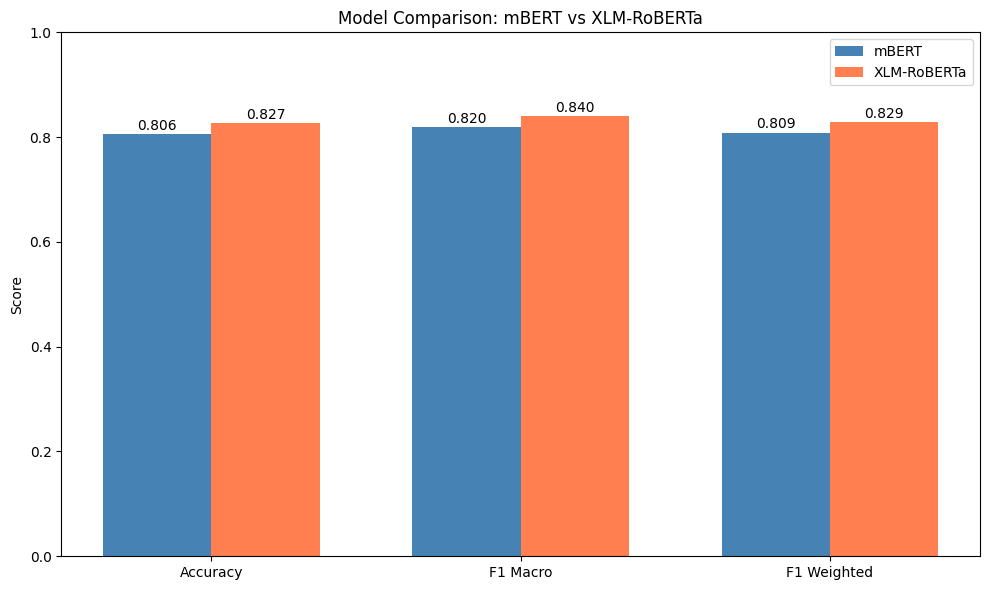


SUMMARY
mBERT - Accuracy: 0.8060, F1 Macro: 0.8197
XLM-R - Accuracy: 0.8274, F1 Macro: 0.8398
IndoBERT - Accuracy: 0.8360, F1 Macro: 0.8402

✓ XLM-RoBERTa performs better on F1 Macro


In [59]:
# Compare results
metrics = ['eval_accuracy', 'eval_f1_macro', 'eval_f1_weighted']
labels = ['Accuracy', 'F1 Macro', 'F1 Weighted']

mbert_vals = [mbert_results.get(m, 0) for m in metrics]
xlmr_vals = [xlmr_results.get(m, 0) for m in metrics]
indobert_vals = [indobert_results.get(m, 0) for m in metrics]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, mbert_vals, width, label='mBERT', color='steelblue')
bars2 = ax.bar(x + width/2, xlmr_vals, width, label='XLM-RoBERTa', color='coral')

ax.set_ylabel('Score')
ax.set_title('Model Comparison: mBERT vs XLM-RoBERTa')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.set_ylim(0, 1)

for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

# Summary
print("\nSUMMARY")
print("=" * 40)
print(f"mBERT - Accuracy: {mbert_results.get('eval_accuracy', 0):.4f}, F1 Macro: {mbert_results.get('eval_f1_macro', 0):.4f}")
print(f"XLM-R - Accuracy: {xlmr_results.get('eval_accuracy', 0):.4f}, F1 Macro: {xlmr_results.get('eval_f1_macro', 0):.4f}")
print(f"IndoBERT - Accuracy: {indobert_results.get('eval_accuracy', 0):.4f}, F1 Macro: {indobert_results.get('eval_f1_macro', 0):.4f}")

# Winner
if mbert_results.get('eval_f1_macro', 0) > xlmr_results.get('eval_f1_macro', 0):
    print("\n✓ mBERT performs better on F1 Macro")
else:
    print("\n✓ XLM-RoBERTa performs better on F1 Macro")

In [60]:
def test_model_output(model_path, test_texts, max_length, show_all_probs=True):
    """
    Test model output dengan sample teks.

    Args:
        model_path: Path ke model yang sudah di-save
        test_texts: List of texts untuk di-test
        show_all_probs: Tampilkan probabilitas semua kelas
        max_length: Panjang maksimum untuk tokenisasi
    """
    print(f"\nTesting model: {model_path}")
    print("=" * 60)

    # Load model and tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForSequenceClassification.from_pretrained(model_path)
    model.eval()

    if torch.cuda.is_available():
        model = model.cuda()

    for text in test_texts:
        print(f"\nInput: {text}")

        # Preprocess
        cleaned = clean_text(text)
        inputs = tokenizer(
            cleaned,
            return_tensors="pt",
            truncation=True,
            max_length=max_length,
            padding=True
        )

        if torch.cuda.is_available():
            inputs = {k: v.cuda() for k, v in inputs.items()}

        # Predict
        with torch.no_grad():
            outputs = model(**inputs)
            probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
            pred = torch.argmax(probs, dim=-1).item()
            confidence = probs[0][pred].item()

        print(f"Prediction: {LABEL_NAMES[pred]} ({confidence:.2%})")

        if show_all_probs:
            print("All probabilities:")
            for i in range(NUM_LABELS):
                bar = "█" * int(probs[0][i].item() * 20)
                print(f"  {LABEL_NAMES[i]:10s}: {probs[0][i].item():.3f} {bar}")

    # Cleanup
    del model
    torch.cuda.empty_cache()


# Test texts
test_texts = [
    "Wah senang banget hari ini! Akhirnya lulus juga 🎉",
    "Sedih banget denger berita itu, semoga keluarganya tabah",
    "Marah banget gue sama dia! Udah dikasih tau berkali-kali",
    "Biasa aja sih, ga ada yang spesial",
    "Kaget banget ternyata dia yang menang!",
    "Takut banget naik roller coaster, tapi seru juga",
    "Aku percaya kamu pasti bisa, semangat ya!"
]

# Test mBERT
test_model_output(OUTPUT_DIR_MBERT, test_texts, MAX_LENGTH_MBERT, show_all_probs=True)

# Test XLM-RoBERTa
test_model_output(OUTPUT_DIR_XLMR, test_texts, MAX_LENGTH_XLMR, show_all_probs=True)

# Test IndoBERT
test_model_output(OUTPUT_DIR_INDOBERT, test_texts, MAX_LENGTH_INDOBERT, show_all_probs=True)




Testing model: ./results/mbert


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Input: Wah senang banget hari ini! Akhirnya lulus juga 🎉
Prediction: senang (94.55%)
All probabilities:
  senang    : 0.946 ██████████████████
  percaya   : 0.008 
  terkejut  : 0.007 
  netral    : 0.029 
  takut     : 0.003 
  sedih     : 0.003 
  marah     : 0.005 

Input: Sedih banget denger berita itu, semoga keluarganya tabah
Prediction: sedih (56.37%)
All probabilities:
  senang    : 0.140 ██
  percaya   : 0.051 █
  terkejut  : 0.020 
  netral    : 0.141 ██
  takut     : 0.027 
  sedih     : 0.564 ███████████
  marah     : 0.057 █

Input: Marah banget gue sama dia! Udah dikasih tau berkali-kali
Prediction: marah (60.95%)
All probabilities:
  senang    : 0.189 ███
  percaya   : 0.003 
  terkejut  : 0.012 
  netral    : 0.057 █
  takut     : 0.092 █
  sedih     : 0.038 
  marah     : 0.609 ████████████

Input: Biasa aja sih, ga ada yang spesial
Prediction: netral (72.49%)
All probabilities:
  senang    : 0.021 
  percaya   : 0.012 
  terkejut  : 0.039 
  netral    : 0.725 ███████

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Input: Wah senang banget hari ini! Akhirnya lulus juga 🎉
Prediction: senang (98.64%)
All probabilities:
  senang    : 0.986 ███████████████████
  percaya   : 0.001 
  terkejut  : 0.002 
  netral    : 0.007 
  takut     : 0.000 
  sedih     : 0.001 
  marah     : 0.001 

Input: Sedih banget denger berita itu, semoga keluarganya tabah
Prediction: sedih (98.91%)
All probabilities:
  senang    : 0.003 
  percaya   : 0.001 
  terkejut  : 0.002 
  netral    : 0.002 
  takut     : 0.001 
  sedih     : 0.989 ███████████████████
  marah     : 0.002 

Input: Marah banget gue sama dia! Udah dikasih tau berkali-kali
Prediction: marah (94.55%)
All probabilities:
  senang    : 0.008 
  percaya   : 0.001 
  terkejut  : 0.010 
  netral    : 0.015 
  takut     : 0.007 
  sedih     : 0.013 
  marah     : 0.946 ██████████████████

Input: Biasa aja sih, ga ada yang spesial
Prediction: netral (63.25%)
All probabilities:
  senang    : 0.088 █
  percaya   : 0.007 
  terkejut  : 0.046 
  netral    : 0.632 ██

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Input: Wah senang banget hari ini! Akhirnya lulus juga 🎉
Prediction: senang (95.53%)
All probabilities:
  senang    : 0.955 ███████████████████
  percaya   : 0.003 
  terkejut  : 0.003 
  netral    : 0.036 
  takut     : 0.001 
  sedih     : 0.001 
  marah     : 0.000 

Input: Sedih banget denger berita itu, semoga keluarganya tabah
Prediction: netral (44.86%)
All probabilities:
  senang    : 0.203 ████
  percaya   : 0.011 
  terkejut  : 0.005 
  netral    : 0.449 ████████
  takut     : 0.007 
  sedih     : 0.313 ██████
  marah     : 0.013 

Input: Marah banget gue sama dia! Udah dikasih tau berkali-kali
Prediction: senang (44.76%)
All probabilities:
  senang    : 0.448 ████████
  percaya   : 0.018 
  terkejut  : 0.337 ██████
  netral    : 0.075 █
  takut     : 0.009 
  sedih     : 0.023 
  marah     : 0.091 █

Input: Biasa aja sih, ga ada yang spesial
Prediction: netral (62.91%)
All probabilities:
  senang    : 0.230 ████
  percaya   : 0.031 
  terkejut  : 0.029 
  netral    : 0.629 

Confusion Matrix - mBERT


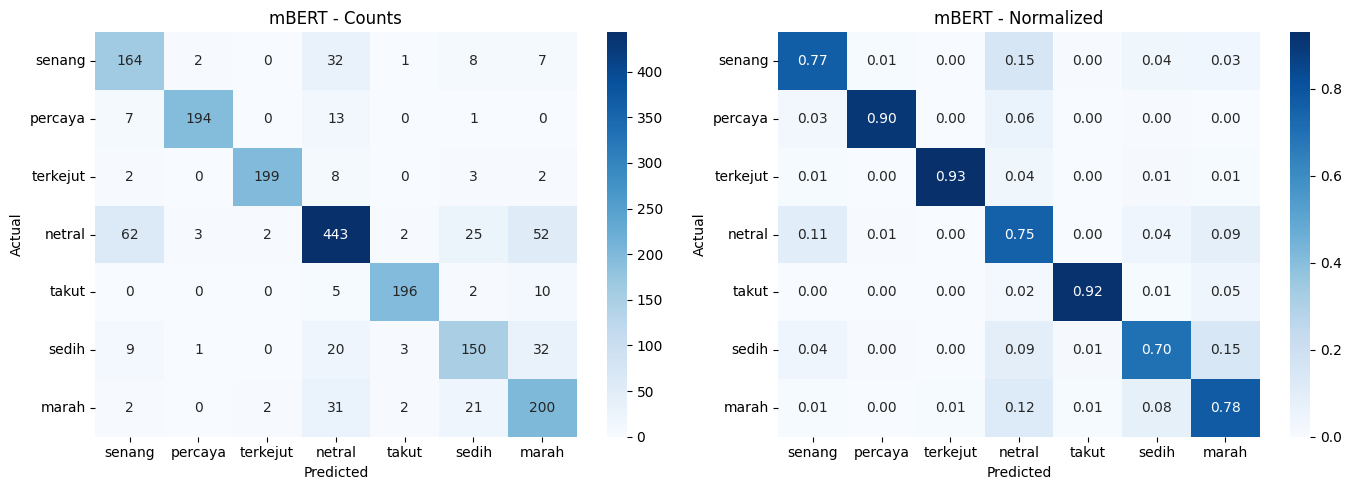


Confusion Matrix - XLM-RoBERTa


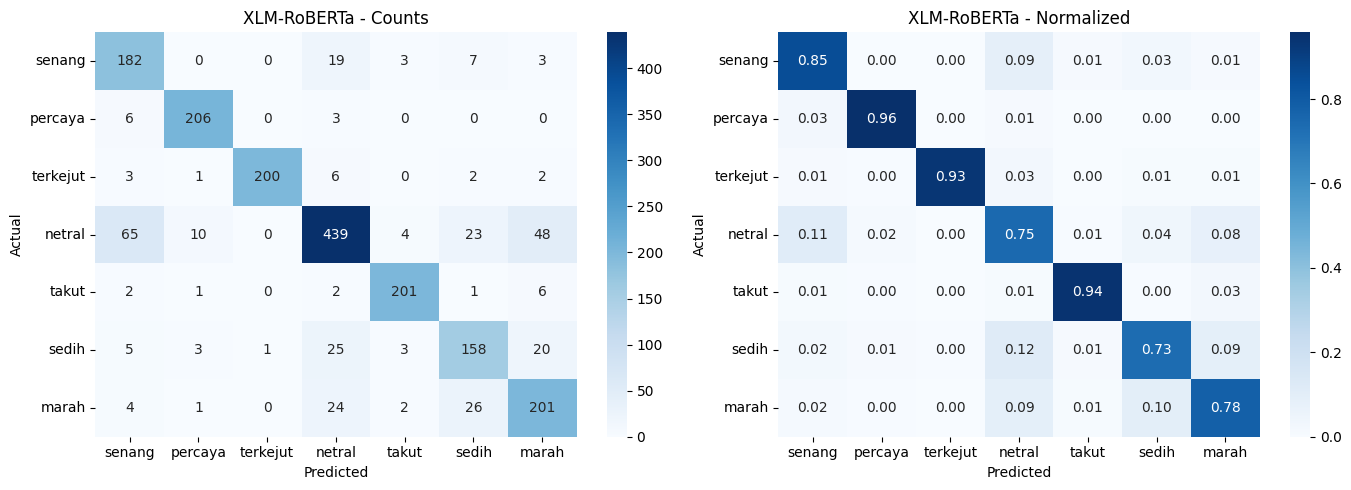

In [61]:
def plot_confusion_matrix(trainer, tokenized_test, model_name):
    """Plot confusion matrix untuk model."""
    predictions = trainer.predict(tokenized_test)
    preds = np.argmax(predictions.predictions, axis=-1)
    labels = predictions.label_ids

    cm = confusion_matrix(labels, preds)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Raw counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[LABEL_NAMES[i] for i in range(NUM_LABELS)],
                yticklabels=[LABEL_NAMES[i] for i in range(NUM_LABELS)],
                ax=axes[0])
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')
    axes[0].set_title(f'{model_name} - Counts')

    # Normalized
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=[LABEL_NAMES[i] for i in range(NUM_LABELS)],
                yticklabels=[LABEL_NAMES[i] for i in range(NUM_LABELS)],
                ax=axes[1])
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Actual')
    axes[1].set_title(f'{model_name} - Normalized')

    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{model_name.lower().replace("-", "_")}.png', dpi=150)
    plt.show()


print("Confusion Matrix - mBERT")
plot_confusion_matrix(mbert_trainer, mbert_tokenized['test'], 'mBERT')

print("\nConfusion Matrix - XLM-RoBERTa")
plot_confusion_matrix(xlmr_trainer, xlmr_tokenized['test'], 'XLM-RoBERTa')

In [ ]:
import shutil

drive_path = "/content/drive/MyDrive/emotion_classification_models"
os.makedirs(drive_path, exist_ok=True)

if os.path.exists(OUTPUT_DIR_MBERT):
    shutil.copytree(OUTPUT_DIR_MBERT, os.path.join(drive_path, "mbert"), dirs_exist_ok=True)
    print(f"✓ mBERT saved to {drive_path}/mbert")

if os.path.exists(OUTPUT_DIR_XLMR):
    shutil.copytree(OUTPUT_DIR_XLMR, os.path.join(drive_path, "xlmr"), dirs_exist_ok=True)
    print(f"✓ XLM-R saved to {drive_path}/xlmr")

# Save comparison chart
if os.path.exists('model_comparison.png'):
    shutil.copy('model_comparison.png', drive_path)
    print(f"✓ Chart saved to {drive_path}/model_comparison.png")

print("\nAll models saved to Google Drive!")

In [42]:
def predict_emotion(text, model_path=OUTPUT_DIR_XLMR):
    """
    Prediksi emosi untuk teks baru.

    Args:
        text: Teks yang akan diprediksi
        model_path: Path ke model (default: mBERT)

    Returns:
        tuple: (emotion_name, confidence)
    """
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForSequenceClassification.from_pretrained(model_path)
    model.eval()

    if torch.cuda.is_available():
        model = model.cuda()

    cleaned = clean_text(text)
    inputs = tokenizer(cleaned, return_tensors="pt", truncation=True, max_length=MAX_LENGTH_XLMR, padding=True)

    if torch.cuda.is_available():
        inputs = {k: v.cuda() for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
        pred = torch.argmax(probs, dim=-1).item()
        confidence = probs[0][pred].item()

    return LABEL_NAMES[pred], confidence


# Quick test
emotion, conf = predict_emotion("saya sangat TIDAK Senang banget hari ini!")
print(f"Prediction: {emotion} ({conf:.2%})")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Prediction: sedih (63.32%)
